<a href="https://www.kaggle.com/code/jfaisal/gcn-soil-moisture?scriptVersionId=342388675" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# AIML505 Course Project — Group J 
**Soil Moisture Forecasting and Smart Irrigation Decision Support**

**Track B: Graph based models**

**Team:** Jobayer Faisal Fahim (2026-2-74-014) · Md. Rafiqul Islam (2026-2-74-025) 

**Dataset:** [Bhopal AgriTech Hybrid IoT Dataset for Predictive Irrigation (Kaggle)](https://www.kaggle.com/datasets/akshaymp08/bhopal-agritech-dataset-for-predictive-irrigation)


# GCN - Graph Convolutional Network 

## Setup — Load data, build graph, build windows (same as main notebook)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
import time
warnings.filterwarnings("ignore")

DATA_PATH = "/kaggle/input/datasets/akshaymp08/bhopal-agritech-dataset-for-predictive-irrigation/Bhopal-AgriTech Hybrid IoT Dataset for Predictive Irrigation.csv"
df = pd.read_csv(DATA_PATH)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

target_col = "soil_moisture_next_1m"
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()
print(f"Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")

Train: 33,352 rows | Test: 8,339 rows


In [2]:
def eval_metrics(y_true, y_pred):
    return (
        np.sqrt(mean_squared_error(y_true, y_pred)),
        mean_absolute_error(y_true, y_pred),
        r2_score(y_true, y_pred),
    )

def mean_absolute_percentage_error_safe(y_true, y_pred, epsilon=1e-6):
    """Safe MAPE — avoids divide-by-near-zero blowups."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), epsilon)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def count_params(model):
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))

def mean_absolute_percentage_error_safe(y_true, y_pred, epsilon=1e-6):
    """Safe MAPE — avoids divide-by-near-zero blowups."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), epsilon)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def count_params(model):
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))


graph_nodes = ["Soil_Moisture", "Temperature", "Humidity", "irrigation_status", "Hour_sin", "Hour_cos"]
n_nodes = len(graph_nodes)

corr_graph = df[graph_nodes].corr().values
np.fill_diagonal(corr_graph, 0)

edge_index_list, edge_weight_list = [], []
for i in range(n_nodes):
    for j in range(n_nodes):
        if i != j:
            edge_index_list.append([i, j])
            edge_weight_list.append(abs(corr_graph[i, j]))

edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
print(f"edge_index shape: {edge_index.shape}")

edge_index shape: torch.Size([2, 30])


In [3]:
WINDOW = 60

node_scalers = {}
train_scaled_g, test_scaled_g = {}, {}
for col in graph_nodes:
    sc = MinMaxScaler()
    train_scaled_g[col] = sc.fit_transform(train_df[[col]]).flatten()
    test_scaled_g[col] = sc.transform(test_df[[col]]).flatten()
    node_scalers[col] = sc

target_scaler_g = MinMaxScaler()
train_target_scaled_g = target_scaler_g.fit_transform(train_df[[target_col]]).flatten()
test_target_scaled_g = target_scaler_g.transform(test_df[[target_col]]).flatten()

def build_windows(scaled_dict, target_scaled, window):
    n = len(next(iter(scaled_dict.values())))
    X, y = [], []
    for t in range(n - window):
        snapshot = np.stack([scaled_dict[col][t:t + window] for col in graph_nodes])
        X.append(snapshot)
        y.append(target_scaled[t + window])
    return np.array(X), np.array(y)

X_train_g, y_train_g = build_windows(train_scaled_g, train_target_scaled_g, WINDOW)
X_test_g, y_test_g = build_windows(test_scaled_g, test_target_scaled_g, WINDOW)

y_true_g = target_scaler_g.inverse_transform(y_test_g.reshape(-1, 1)).flatten()
print(f"X_train_g: {X_train_g.shape}  X_test_g: {X_test_g.shape}")

X_train_g: (33292, 6, 60)  X_test_g: (8279, 6, 60)


In [4]:
!pip install torch_geometric --no-deps -q
!pip install networkx decorator six -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.3 MB/s eta 0:00:00


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_t = torch.tensor(X_train_g, dtype=torch.float32)
y_train_t = torch.tensor(y_train_g, dtype=torch.float32).unsqueeze(-1)
X_test_t = torch.tensor(X_test_g, dtype=torch.float32)

edge_index_dev = edge_index.to(device)
edge_weight_dev = edge_weight.to(device)

batch_size = 128
n_batches = len(X_train_t) // batch_size
loss_fn = nn.MSELoss()

Using device: cpu


## GCN Model



In [6]:
from torch_geometric.nn import GCNConv

class GCNForecaster(nn.Module):
    def __init__(self, in_channels, hidden_channels=32):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.readout = nn.Linear(hidden_channels * n_nodes, 1)

    def forward(self, x, edge_index, edge_weight):
        outs = []
        for b in range(x.shape[0]):
            h = F.relu(self.conv1(x[b], edge_index, edge_weight))
            h = F.relu(self.conv2(h, edge_index, edge_weight))
            outs.append(h.flatten())
        return self.readout(torch.stack(outs))

print("GCN model class defined.")

GCN model class defined.


## Extended Training — watch the loss curve


In [7]:
N_EPOCHS =  50 

model = GCNForecaster(in_channels=WINDOW).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses = []


train_start = time.time() 
model.train()
for epoch in range(N_EPOCHS):
    epoch_loss = 0.0
    perm = torch.randperm(len(X_train_t))
    for i in range(n_batches):
        idx = perm[i*batch_size:(i+1)*batch_size]
        xb, yb = X_train_t[idx].to(device), y_train_t[idx].to(device)
        optimizer.zero_grad()
        pred = model(xb, edge_index_dev, edge_weight_dev)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / n_batches
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1:3d}/{N_EPOCHS}: loss={avg_loss:.6f}")

Epoch   1/50: loss=0.014745
Epoch   2/50: loss=0.000921
Epoch   3/50: loss=0.000697
Epoch   4/50: loss=0.000567
Epoch   5/50: loss=0.000502
Epoch   6/50: loss=0.000470
Epoch   7/50: loss=0.000428
Epoch   8/50: loss=0.000412
Epoch   9/50: loss=0.000383
Epoch  10/50: loss=0.000392
Epoch  11/50: loss=0.000394
Epoch  12/50: loss=0.000384
Epoch  13/50: loss=0.000390
Epoch  14/50: loss=0.000374
Epoch  15/50: loss=0.000373
Epoch  16/50: loss=0.000377
Epoch  17/50: loss=0.000364
Epoch  18/50: loss=0.000376
Epoch  19/50: loss=0.000381
Epoch  20/50: loss=0.000402
Epoch  21/50: loss=0.000360
Epoch  22/50: loss=0.000361
Epoch  23/50: loss=0.000384
Epoch  24/50: loss=0.000364
Epoch  25/50: loss=0.000378
Epoch  26/50: loss=0.000369
Epoch  27/50: loss=0.000374
Epoch  28/50: loss=0.000370
Epoch  29/50: loss=0.000351
Epoch  30/50: loss=0.000373
Epoch  31/50: loss=0.000359
Epoch  32/50: loss=0.000369
Epoch  33/50: loss=0.000358
Epoch  34/50: loss=0.000356
Epoch  35/50: loss=0.000358
Epoch  36/50: loss=0

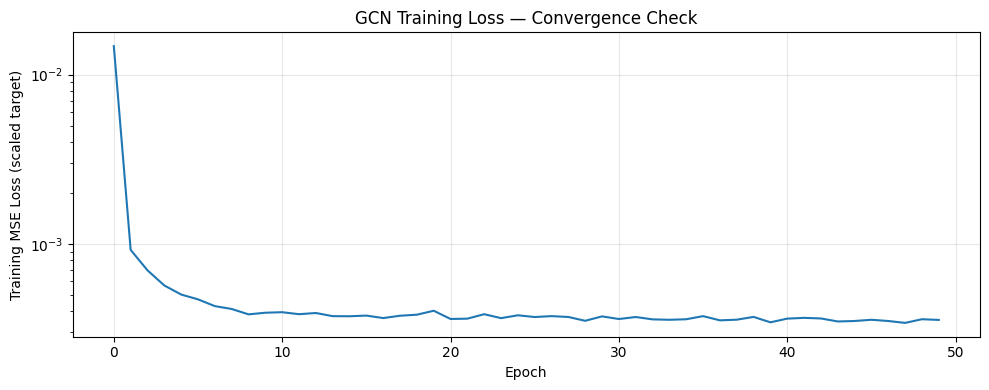


First 5 epochs avg loss: 0.003486
Last 5 epochs avg loss:  0.000352
Loss still decreasing in final 5 epochs: True


In [8]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training MSE Loss (scaled target)")
plt.title(f"GCN Training Loss — Convergence Check")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFirst 5 epochs avg loss: {np.mean(train_losses[:5]):.6f}")
print(f"Last 5 epochs avg loss:  {np.mean(train_losses[-5:]):.6f}")
print(f"Loss still decreasing in final 5 epochs: {train_losses[-1] < train_losses[-5]}")

## Evaluation on held-out test set



In [9]:
def eval_model(m):
    m.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_test_t), batch_size):
            xb = X_test_t[i:i+batch_size].to(device)
            preds.append(m(xb, edge_index_dev, edge_weight_dev).cpu().numpy())
    pred_scaled = np.concatenate(preds).flatten()
    return target_scaler_g.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

pred = eval_model(model)
rmse, mae, r2 = eval_metrics(y_true_g, pred)
mape = mean_absolute_percentage_error_safe(y_true_g, pred)
n_params = count_params(model)
train_time = time.time() - train_start

print(f"GCN ({N_EPOCHS} epochs) — RMSE: {rmse:.4f}  MAE: {mae:.4f}  MAPE: {mape:.2f}%  R2: {r2:.4f}  Train Time: {train_time:.1f}s, num_params: {n_params:,} params")
print()
print("For reference:")
print(f"GCN  Original run (5 epochs):  RMSE: 1.159149  MAE: 0.586669  R2: 0.987775  MAPE: 2.034185%   Train Time: 387.600491s, num_params: 3201.0 params")

GCN (50 epochs) — RMSE: 1.3096  MAE: 0.8477  MAPE: 2.92%  R2: 0.9844  Train Time: 2255.6s, num_params: 3,201 params

For reference:
GCN  Original run (5 epochs):  RMSE: 1.159149  MAE: 0.586669  R2: 0.987775  MAPE: 2.034185%   Train Time: 387.600491s, num_params: 3201.0 params


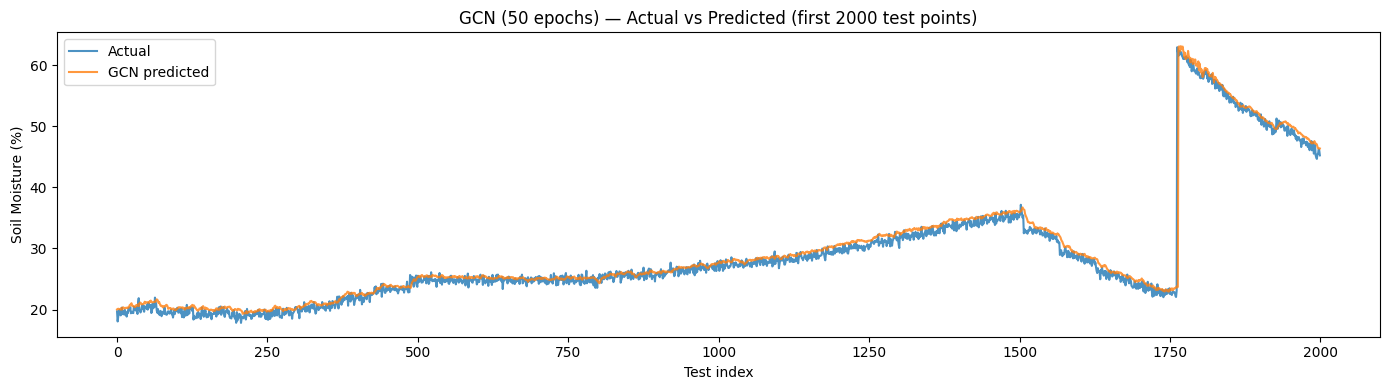

In [10]:
plt.figure(figsize=(14, 4))
plt.plot(y_true_g[:2000], label="Actual", alpha=0.8)
plt.plot(pred[:2000], label="GCN predicted", alpha=0.8)
plt.title(f"GCN ({N_EPOCHS} epochs) — Actual vs Predicted (first 2000 test points)")
plt.xlabel("Test index")
plt.ylabel("Soil Moisture (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
result_row = pd.DataFrame([{
    "model": "GCN",
    "epochs": N_EPOCHS,
    "rmse": rmse,
    "mae": mae,
    "mape": mape,
    "r2": r2,
    "training_time_s": train_time,
    "num_params": n_params,
}])
result_row.to_csv("gcn_extended_result.csv", index=False)
result_row

,model,epochs,rmse,mae,mape,r2,training_time_s,num_params
0,GCN,50,1.309628,0.847713,2.915542,0.984395,2255.579689,3201


In [12]:
import glob
import pandas as pd

files = glob.glob("gcn_extended_result.csv")   
combined = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
combined = combined.sort_values("rmse").reset_index(drop=True)
combined

,model,epochs,rmse,mae,mape,r2,training_time_s,num_params
0,GCN,50,1.309628,0.847713,2.915542,0.984395,2255.579689,3201
